In [2]:
!pip install numpy pandas matplotlib seaborn

  Using cached pandas-2.2.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.1-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.57.0-cp312-cp312-win_amd64.whl.metadata (104 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached pillow-11.2.1-cp312-cp312-win_amd64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------------


[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [6]:
import sys
sys.executable

'D:\\usedcarprice\\env\\Scripts\\python.exe'

In [7]:
df = pd.read_csv("../Data/dataset.csv")

In [8]:
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6017 non-null   object 
 8   Engine             5983 non-null   object 
 9   Power              5983 non-null   object 
 10  Seats              5977 non-null   float64
 11  New_Price          824 non-null    object 
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 611.4+ KB


## first handling the missing values

In [30]:
features_with_na = [features for features in df.columns if df[features].isnull().any()]

In [31]:
print(features_with_na)

['Mileage', 'Engine', 'Power', 'Seats', 'New_Price']


In [35]:
for feature in features_with_na:
    print(f"{feature} has {np.round(df[feature].isnull().mean() * 100, 5)} % of missing values")

Mileage has 0.03323 % of missing values
Engine has 0.59811 % of missing values
Power has 0.59811 % of missing values
Seats has 0.69779 % of missing values
New_Price has 86.31002 % of missing values


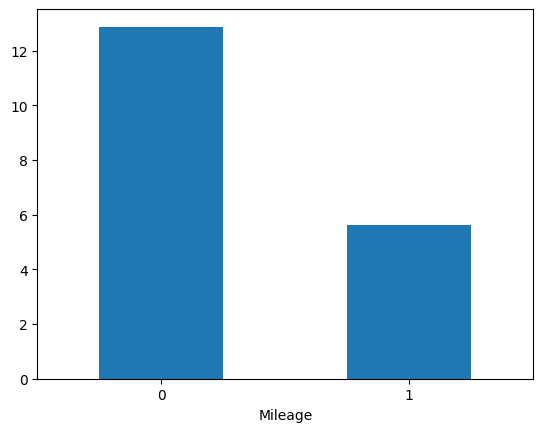

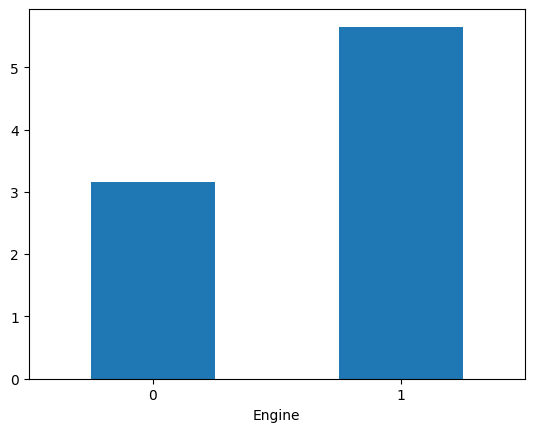

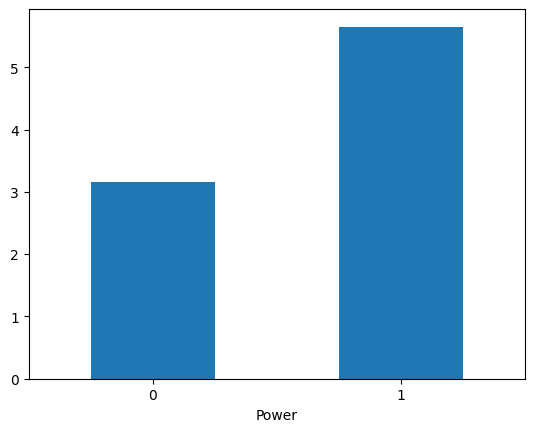

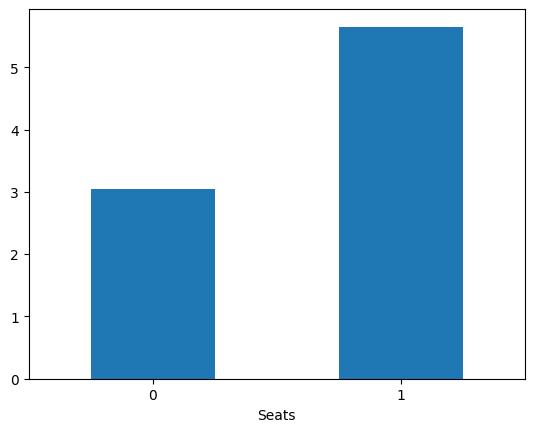

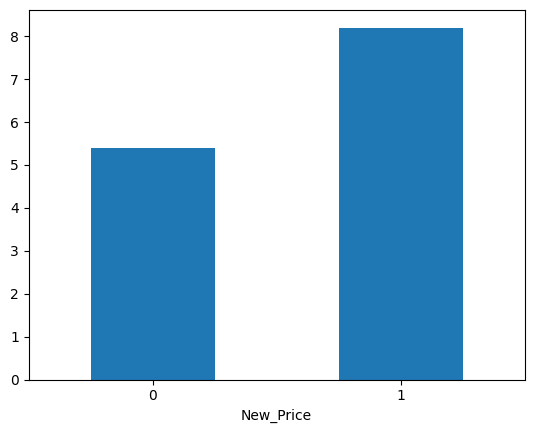

In [42]:
## find the relationship b\w missing values and the target variables(Price)

for feature in features_with_na:
    cdf = df.copy()

    ## map the missing values as 0 and non missing values as 1
    cdf[feature] = np.where(cdf[feature].isnull(), 0, 1)
    cdf.groupby(feature)['Price'].median().plot.bar()
    plt.xticks(rotation=0)
    plt.show()

by this we came to a conclusion that mileage need to be handled because that feature is highly related with the target variable as though other features are also some what related so imputing is a better choice

In [44]:
## find the relationship between the numerical values and categorical values with the target features

In [49]:
## collect the numerical features

num_features = df.select_dtypes(exclude=['object']).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()

In [50]:
print(num_features,cat_features)

['Year', 'Kilometers_Driven', 'Seats', 'Price'] ['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'New_Price']


In [ ]:
## some of the features are in objects and need to be converted to numerical values just leave it for future

<Figure size 500x400 with 0 Axes>

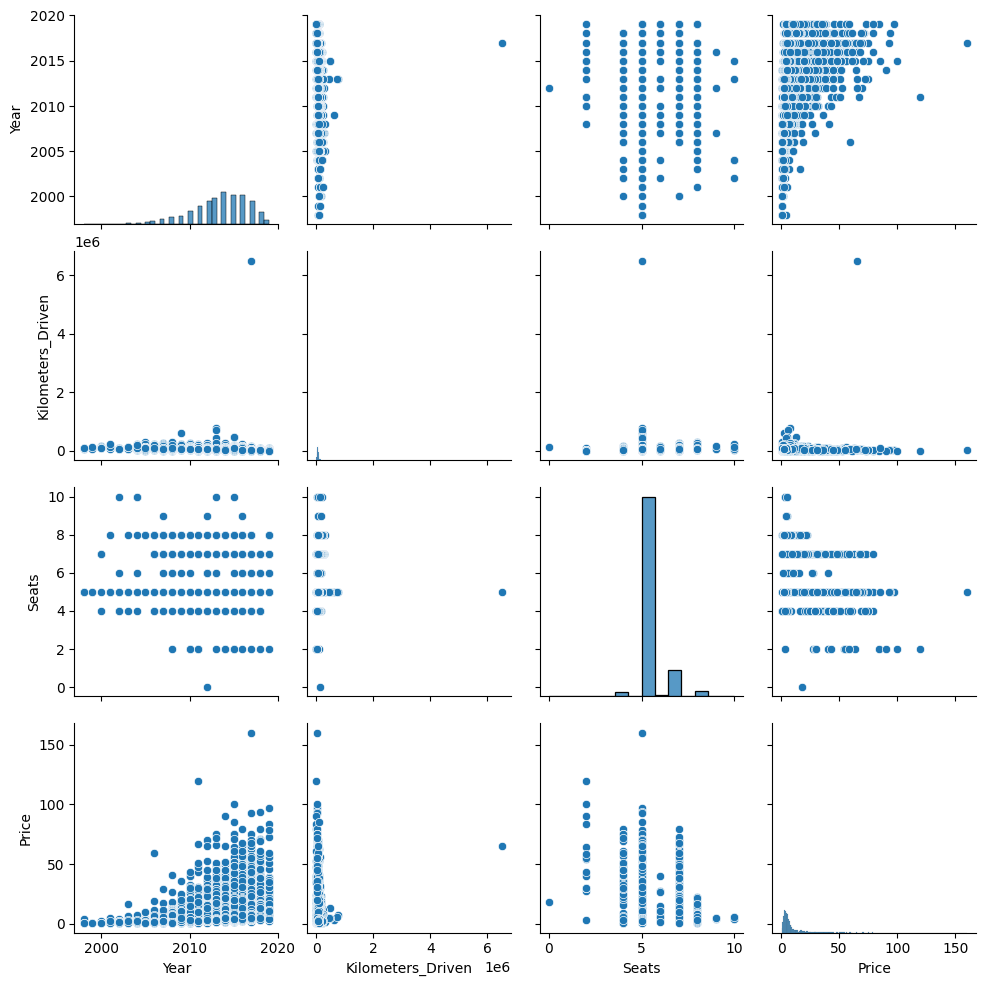

<Figure size 500x400 with 0 Axes>

In [52]:
sns.pairplot(data=df[num_features])
plt.figure(figsize=(5,4))

 year and price as a linear relationship 

In [ ]:
#next we do feature engineering mainly for categorical variables